# Article 4: Single-Agent Benchmark Analysis

This notebook analyzes benchmark results comparing ReAct vs Plan-and-Execute agent architectures on multi-tool queries, measuring success rate, latency, tool usage patterns, and error recovery behavior.

Teaching note: Agent architecture comparison
--------------------------------------------
Effective agent benchmarking requires measuring:
1. **Success rate**: Did the agent complete the task?
2. **Tool efficiency**: How many tools were called? Which ones?
3. **Latency**: Total time including LLM calls + tool execution
4. **Error patterns**: What failure modes exist?

Key architectural differences:
- **ReAct**: Iterative reasoning loop (think → act → observe) - adapts dynamically
- **Plan-Execute**: Upfront planning + sequential execution - fewer LLM calls if plan is good

Neither is universally better - depends on query complexity and failure modes.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style for production-quality charts
# Teaching note: Chart aesthetics
# - seaborn whitegrid: Clean, professional look
# - Figure size (10, 6): Readable in blog posts
# - DPI 300: Publication quality for PNG export
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 11

## Load Benchmark Results

Load results from `results/data/article_04_benchmarks.json` generated by `benchmarks/run_article_04.py`.

In [2]:
# Define paths
PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results" / "data"
CHARTS_DIR = PROJECT_ROOT / "results" / "charts" / "article_04"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

benchmark_file = RESULTS_DIR / "article_04_benchmarks.json"
if not benchmark_file.exists():
    raise FileNotFoundError(
        f"Benchmark file not found: {benchmark_file}\n"
        "Run: uv run python benchmarks/run_article_04.py"
    )

with open(benchmark_file) as f:
    data = json.load(f)

meta = data["metadata"]
print(f"Loaded benchmark data from {benchmark_file}")
print(f"Timestamp:        {meta['timestamp']}")
print(f"Runs per query:   {meta['runs']}")
print(f"Unique queries:   {meta['total_queries']}")
print(f"Categories:       {', '.join(meta['categories'])}")
print(f"Mock mode:        {meta['use_mock']}")


Loaded benchmark data from /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/data/article_04_benchmarks.json
Timestamp:        2026-05-03 11:23:06
Runs per query:   3
Unique queries:   17
Categories:       rag_calculation, database_analysis, code_execution
Mock mode:        False


## Extract Metrics

Extract summary metrics for both agent types.

In [3]:
import statistics

react_summary = data["summaries"]["react"]
plan_summary = data["summaries"]["plan_execute"]
react_results = data["detailed_results"]["react"]
plan_results = data["detailed_results"]["plan_execute"]

react_iters = [r.get("iterations", 0) for r in react_results]
plan_steps = [r.get("steps", 0) for r in plan_results]

# Note: avg_tool_calls is 0 across the run because the benchmark runner reads
# tool calls from chat_history looking for role=="tool", but the LangGraph
# agents emit role=="assistant (action)" (ReAct) or return step_results
# instead of chat_history (Plan-and-Execute). Iteration / step counts are the
# only behavioural proxy in this run. Runner gap, not an agent regression.
print("ReAct Agent")
print(f"  Trials:                 {len(react_results)}")
print(f"  Success Rate:           {react_summary['success_rate']:.1%}")
print(f"  Avg / Median Latency:   {react_summary['avg_latency_ms']:.0f}ms / "
      f"{react_summary['median_latency_ms']:.0f}ms")
print(f"  Mean iterations:        {statistics.mean(react_iters):.2f} "
      f"(median {statistics.median(react_iters):.0f}, max {max(react_iters)})")
print(f"  Failures:               {len(react_results) - sum(r['success'] for r in react_results)}")
print()
print("Plan-and-Execute Agent")
print(f"  Trials:                 {len(plan_results)}")
print(f"  Success Rate:           {plan_summary['success_rate']:.1%}")
print(f"  Avg / Median Latency:   {plan_summary['avg_latency_ms']:.0f}ms / "
      f"{plan_summary['median_latency_ms']:.0f}ms")
print(f"  Mean steps:             {statistics.mean(plan_steps):.2f} "
      f"(median {statistics.median(plan_steps):.0f}, max {max(plan_steps)})")
print(f"  Failures:               {len(plan_results) - sum(r['success'] for r in plan_results)}")


ReAct Agent
  Trials:                 51
  Success Rate:           94.1%
  Avg / Median Latency:   2259ms / 2061ms
  Mean iterations:        4.39 (median 4, max 10)
  Failures:               3

Plan-and-Execute Agent
  Trials:                 51
  Success Rate:           100.0%
  Avg / Median Latency:   2299ms / 1740ms
  Mean steps:             3.39 (median 3, max 10)
  Failures:               0


## Chart 1: Success Rate Comparison

Bar chart comparing task completion success rates between agent architectures.

Teaching note: Success rate interpretation
-------------------------------------------
- **100% success**: Agent completes all queries without errors
- **High success (80-99%)**: Agent is reliable but has edge cases
- **Low success (<80%)**: Agent struggles with query complexity or tool failures

Success rate differences reveal:
- Planning failures (Plan-Execute with bad upfront plan)
- Adaptation failures (ReAct unable to recover from tool errors)
- Architectural strengths/weaknesses on specific query types

Saved: /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/charts/article_04/01_success_rate.png


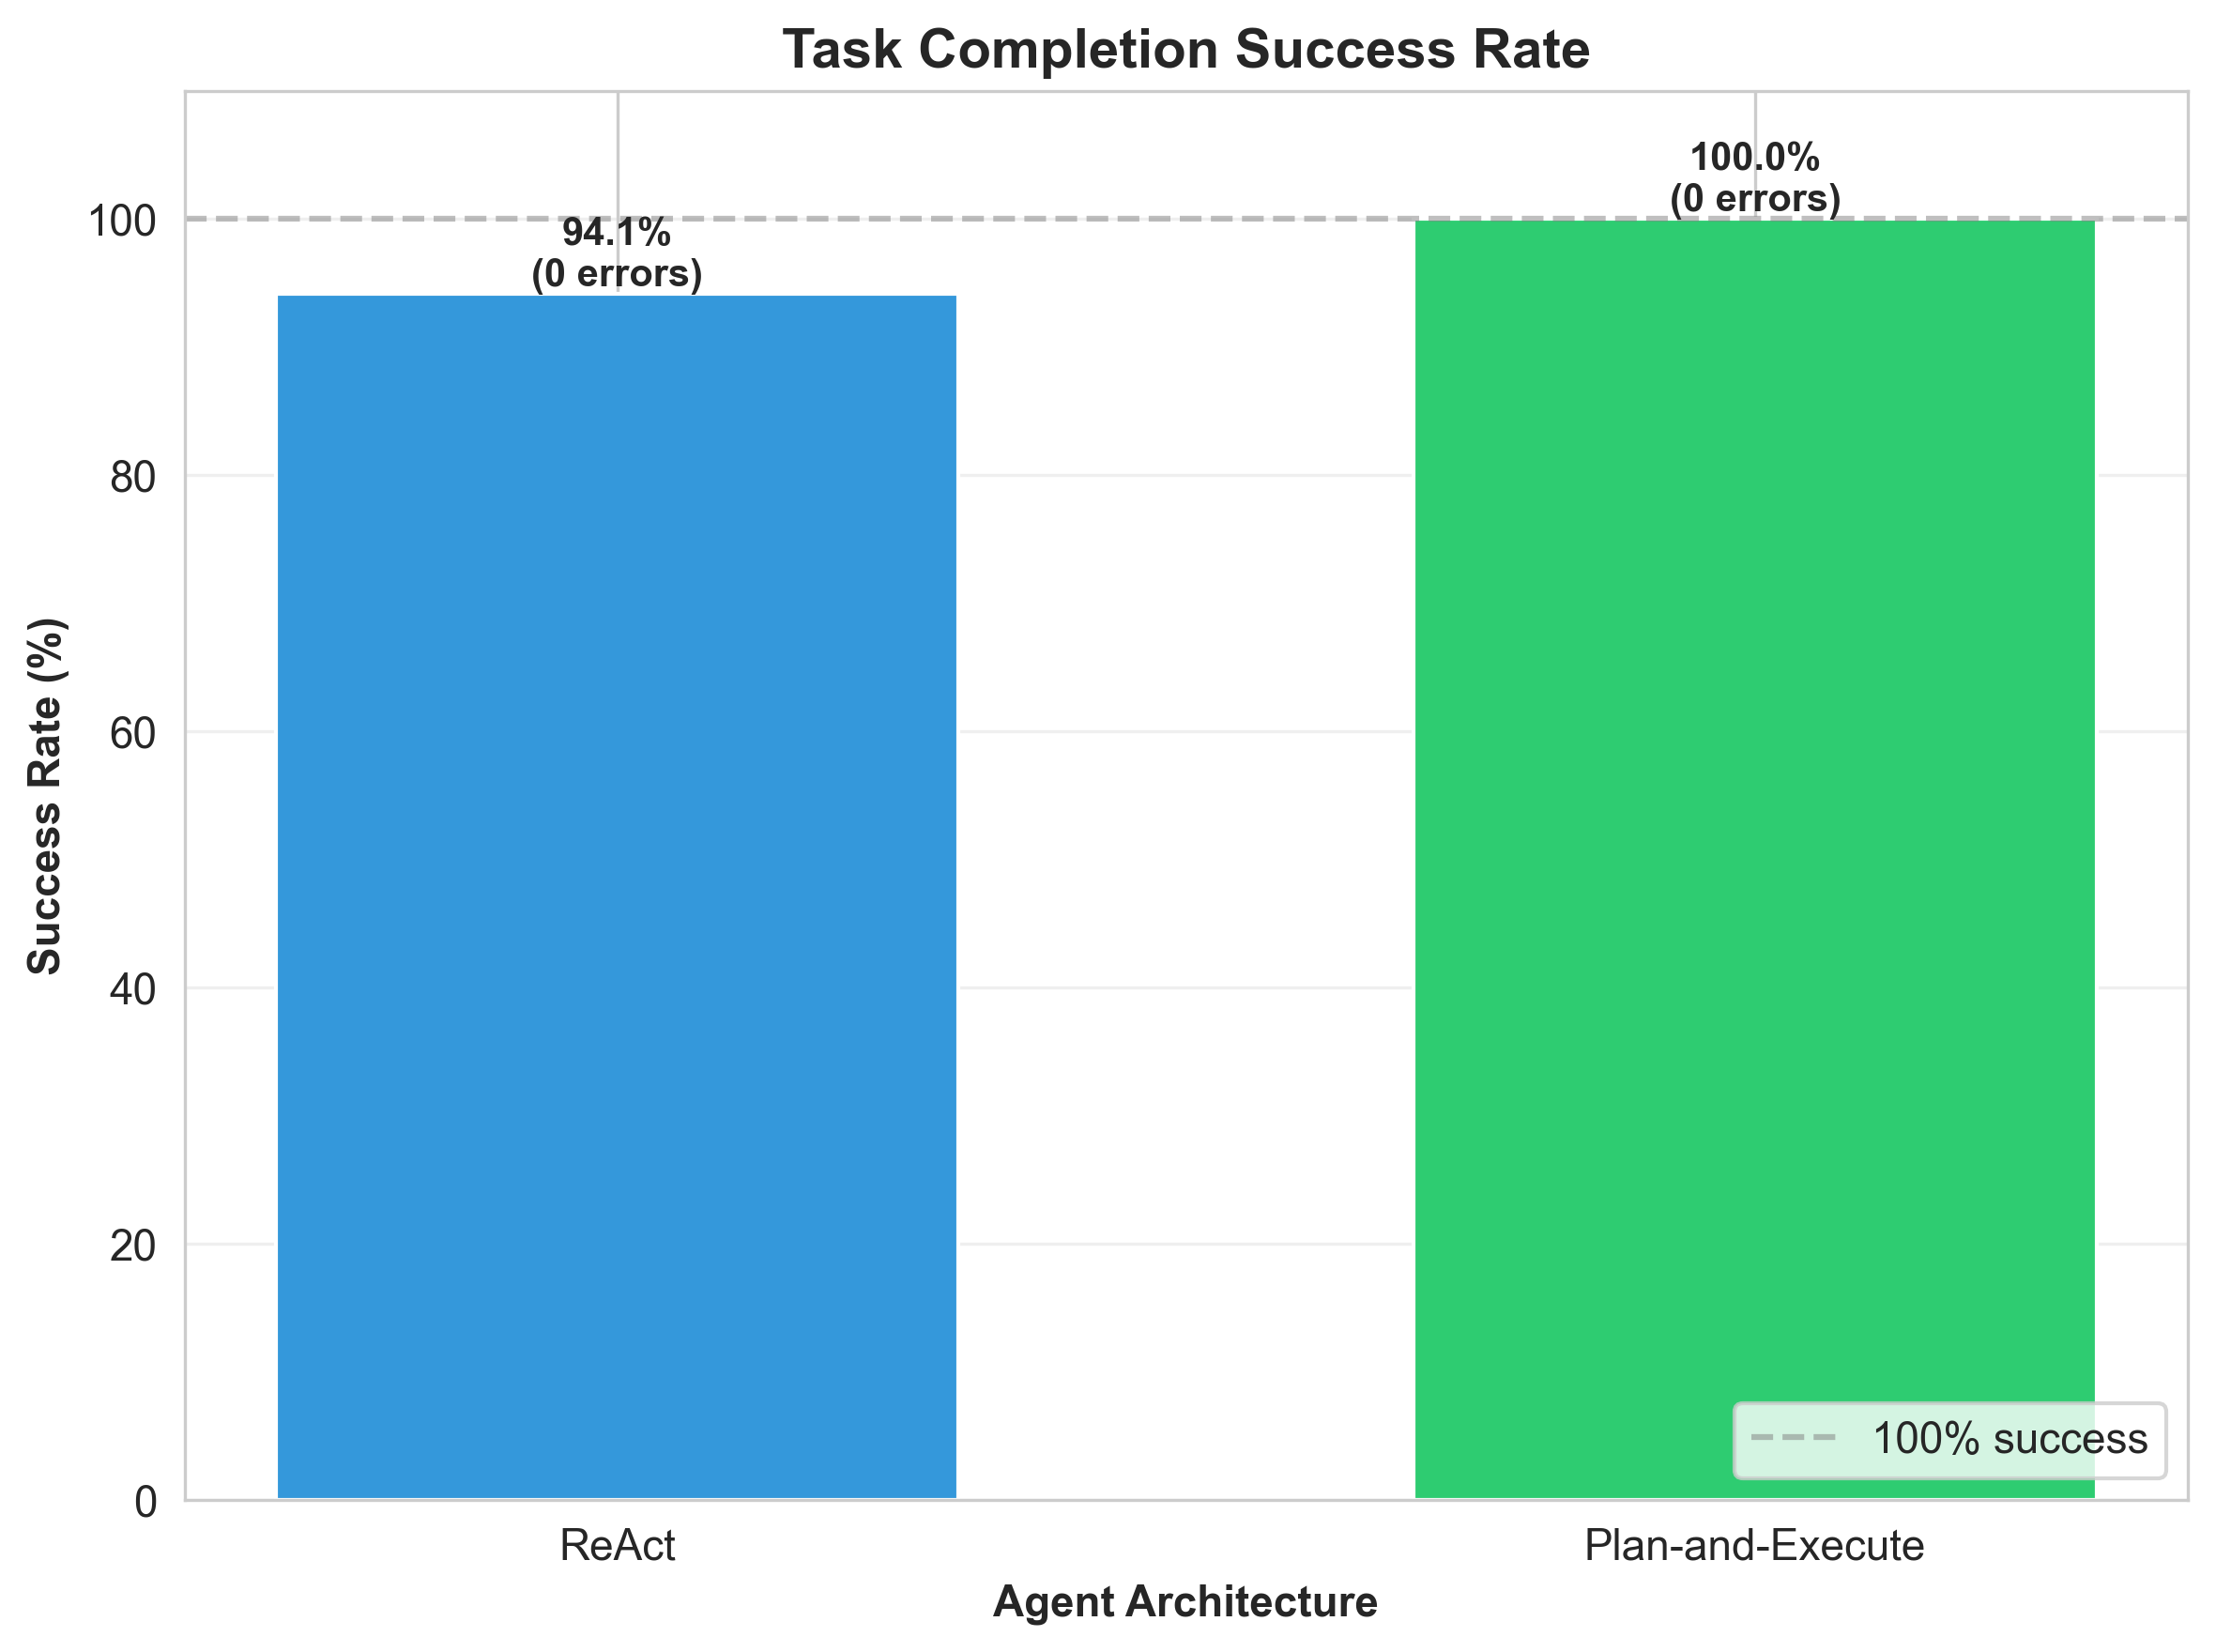

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

# Data for plotting
agents = ["ReAct", "Plan-and-Execute"]
success_rates = [
    react_summary["success_rate"] * 100,
    plan_summary["success_rate"] * 100
]
error_counts = [
    react_summary["error_count"],
    plan_summary["error_count"]
]

x = np.arange(len(agents))
width = 0.6

# Create bars
bars = ax.bar(x, success_rates, width, color=['#3498db', '#2ecc71'])

# Add error count annotations
for i, (bar, err_count) in enumerate(zip(bars, error_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n({err_count} errors)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
ax.set_xlabel('Agent Architecture', fontweight='bold')
ax.set_ylabel('Success Rate (%)', fontweight='bold')
ax.set_title('Task Completion Success Rate', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(agents)
ax.set_ylim(0, 110)  # Extra space for labels
ax.grid(axis='y', alpha=0.3)

# Add reference line at 100%
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='100% success')
ax.legend(loc='lower right')

plt.tight_layout()
output_file = CHARTS_DIR / "01_success_rate.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"Saved: {output_file}")
plt.show()

## Chart 2: Trajectory Length Distribution

Histogram of trajectory length per trial: ReAct reasoning-loop iterations vs Plan-and-Execute plan steps. This is the only behavioural-complexity signal available in this run; tool-call telemetry was not captured (see note in extraction cell above) and will be back-filled in a follow-on run.

Why the comparison is informative even without tool histograms:
- Each ReAct iteration costs one LLM call (the reasoning step) plus zero or one tool calls.
- Each P&E step costs one tool execution after the upfront planning call.
- Distribution shape exposes whether one architecture systematically converges faster or hits the iteration cap more often.


Saved: /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/charts/article_04/02_trajectory_length.png


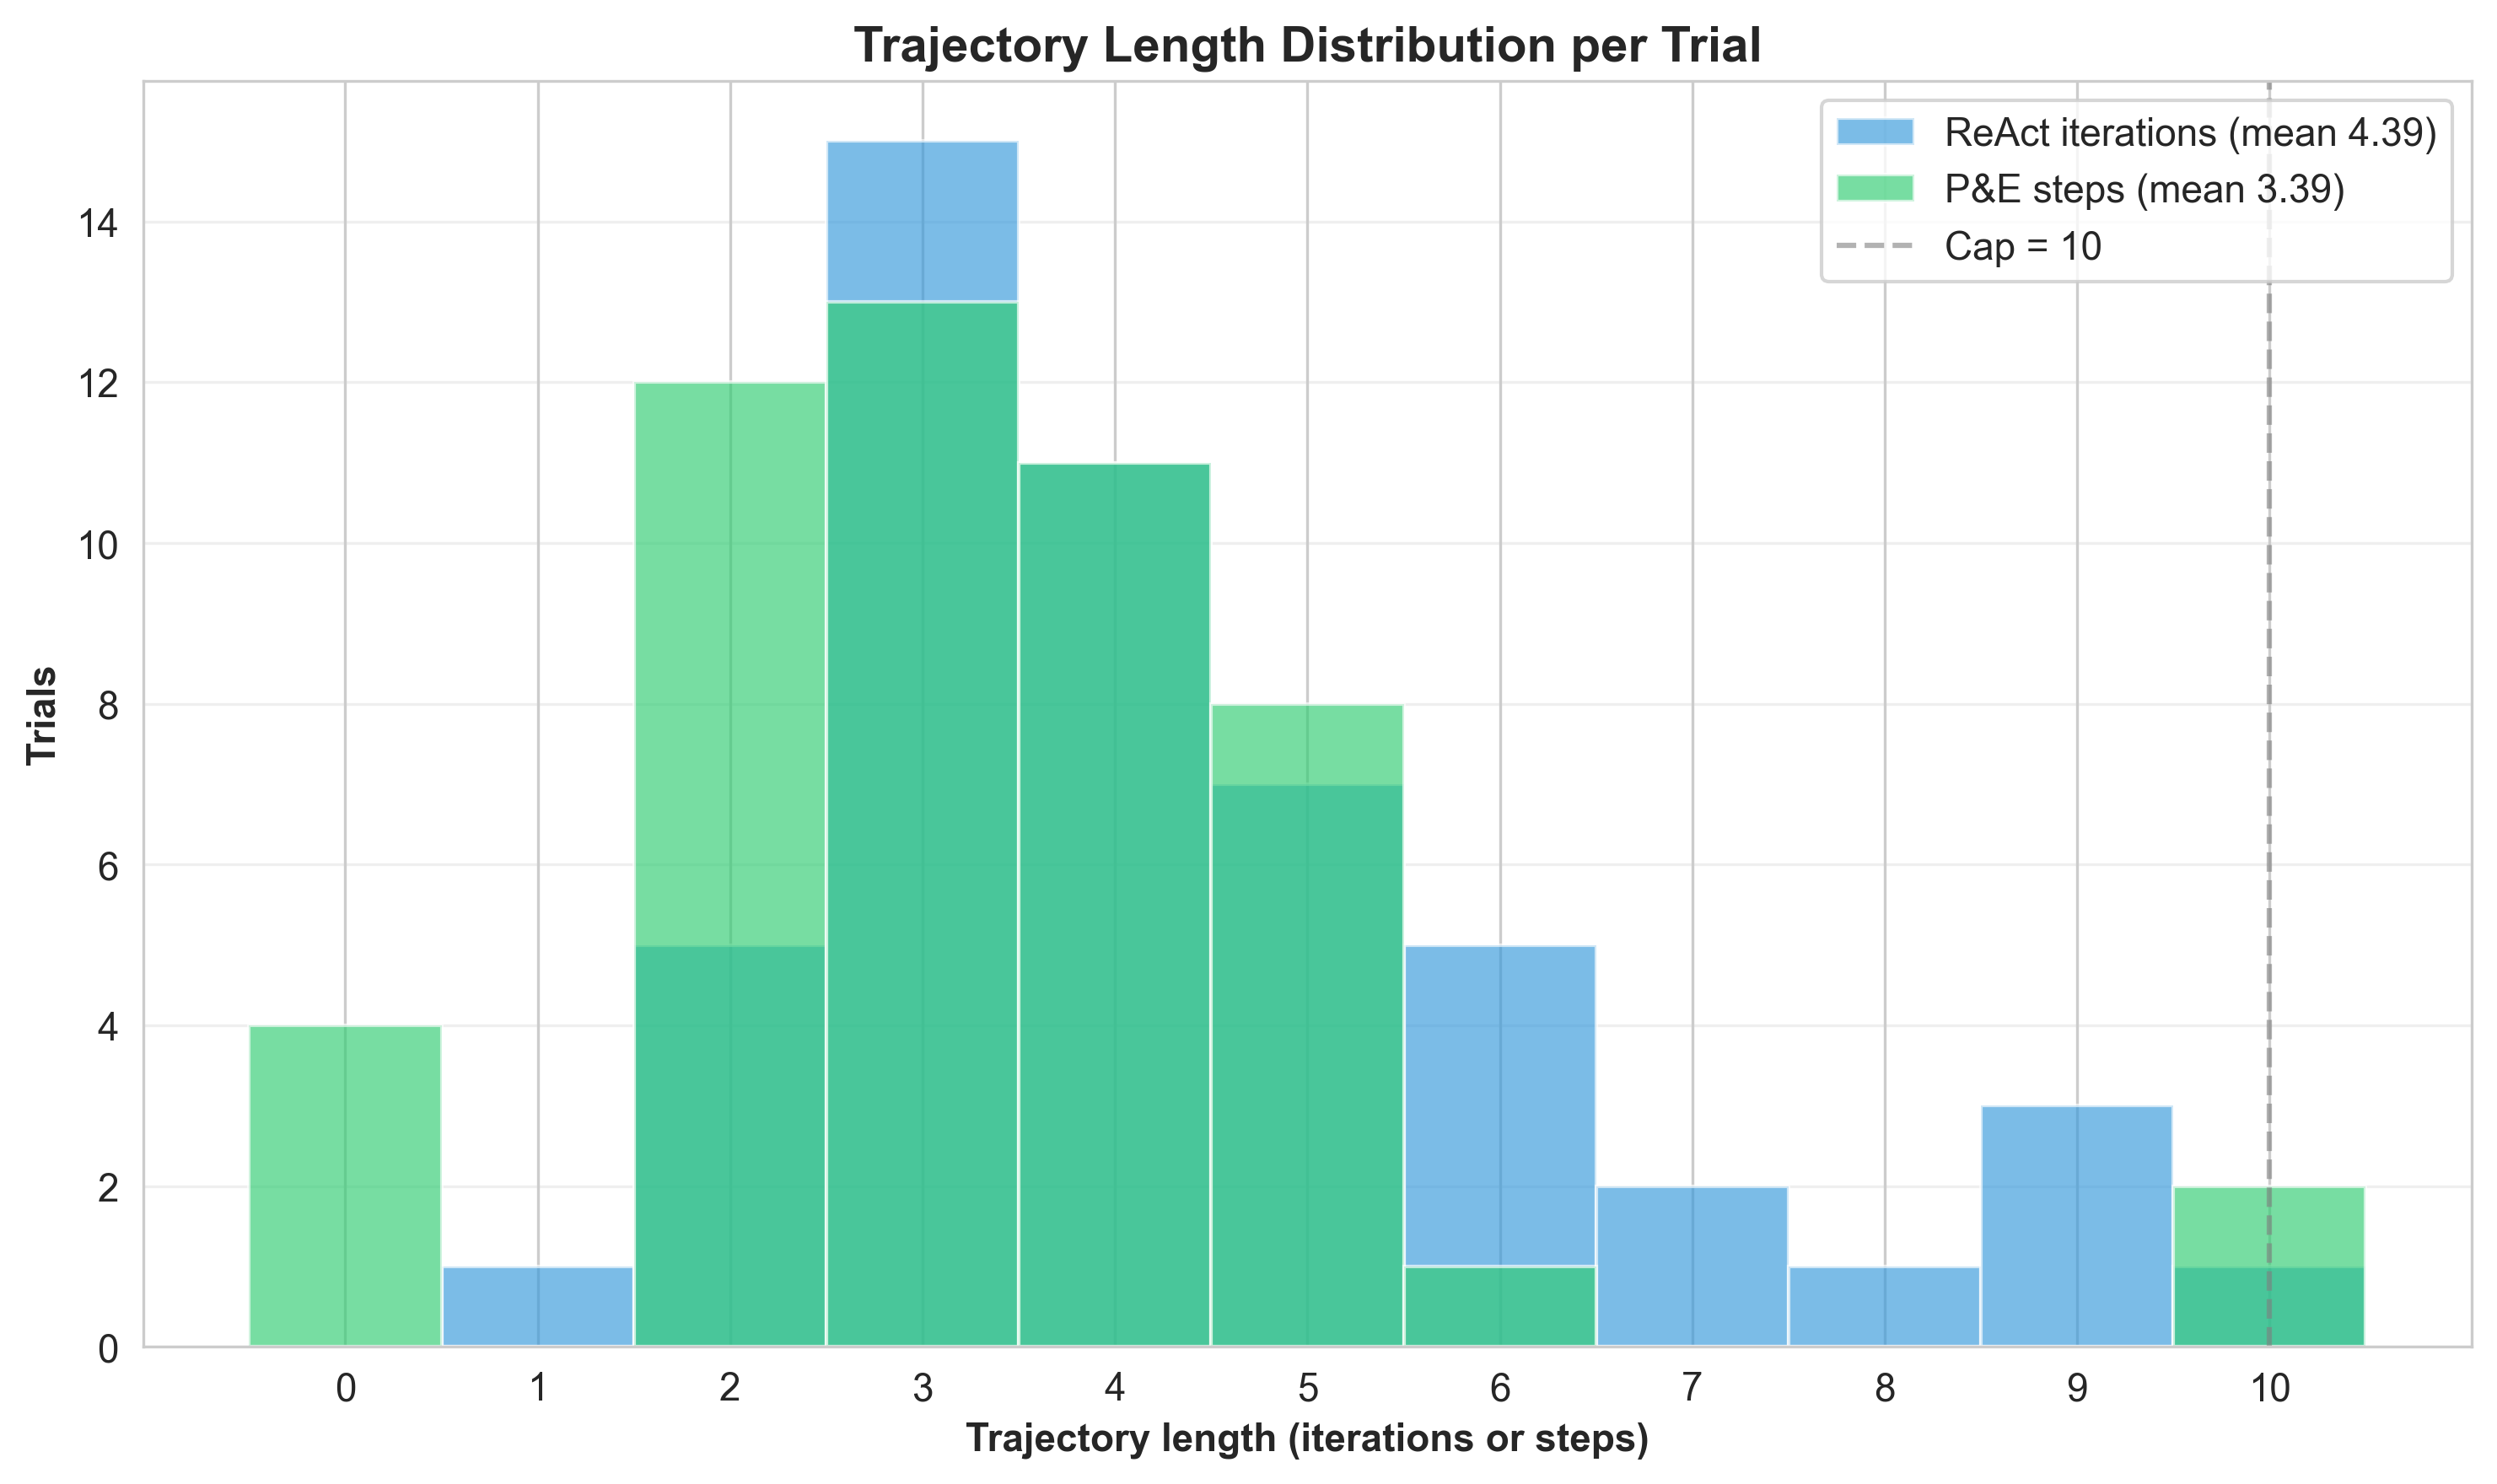

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

react_iters = [r.get("iterations", 0) for r in react_results]
plan_steps = [r.get("steps", 0) for r in plan_results]

cap = max(max(react_iters), max(plan_steps))
bins = np.arange(0, cap + 2) - 0.5  # integer-aligned bins, half-step offset

ax.hist(react_iters, bins=bins, alpha=0.65, color='#3498db',
        label=f'ReAct iterations (mean {np.mean(react_iters):.2f})',
        edgecolor='white')
ax.hist(plan_steps, bins=bins, alpha=0.65, color='#2ecc71',
        label=f'P&E steps (mean {np.mean(plan_steps):.2f})',
        edgecolor='white')

ax.axvline(cap, color='gray', linestyle='--', alpha=0.6,
           label=f'Cap = {cap}')

ax.set_xlabel('Trajectory length (iterations or steps)', fontweight='bold')
ax.set_ylabel('Trials', fontweight='bold')
ax.set_title('Trajectory Length Distribution per Trial', fontsize=14, fontweight='bold')
ax.set_xticks(np.arange(0, cap + 1))
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
output_file = CHARTS_DIR / "02_trajectory_length.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"Saved: {output_file}")
plt.show()


## Chart 3: Latency Distribution

Box plot comparing end-to-end query latency distributions between agent architectures.

Teaching note: Latency comparison
----------------------------------
Latency differences reveal architectural trade-offs:

**ReAct**:
- Pro: Can stop early if answer is found
- Con: Iterative LLM calls add overhead
- Expected: Higher variance (adapts based on query complexity)

**Plan-Execute**:
- Pro: Predictable execution (plan once, execute steps)
- Con: Cannot skip unnecessary steps in plan
- Expected: Lower variance (fixed plan structure)

Median latency = typical user experience
Wide IQR = unpredictable performance

Saved: /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/charts/article_04/03_latency_distribution.png


/var/folders/zm/vdkmvw8j2qx3097ct01h3sbh0000gn/T/ipykernel_25506/1621963687.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(latency_data, labels=agent_labels, patch_artist=True,


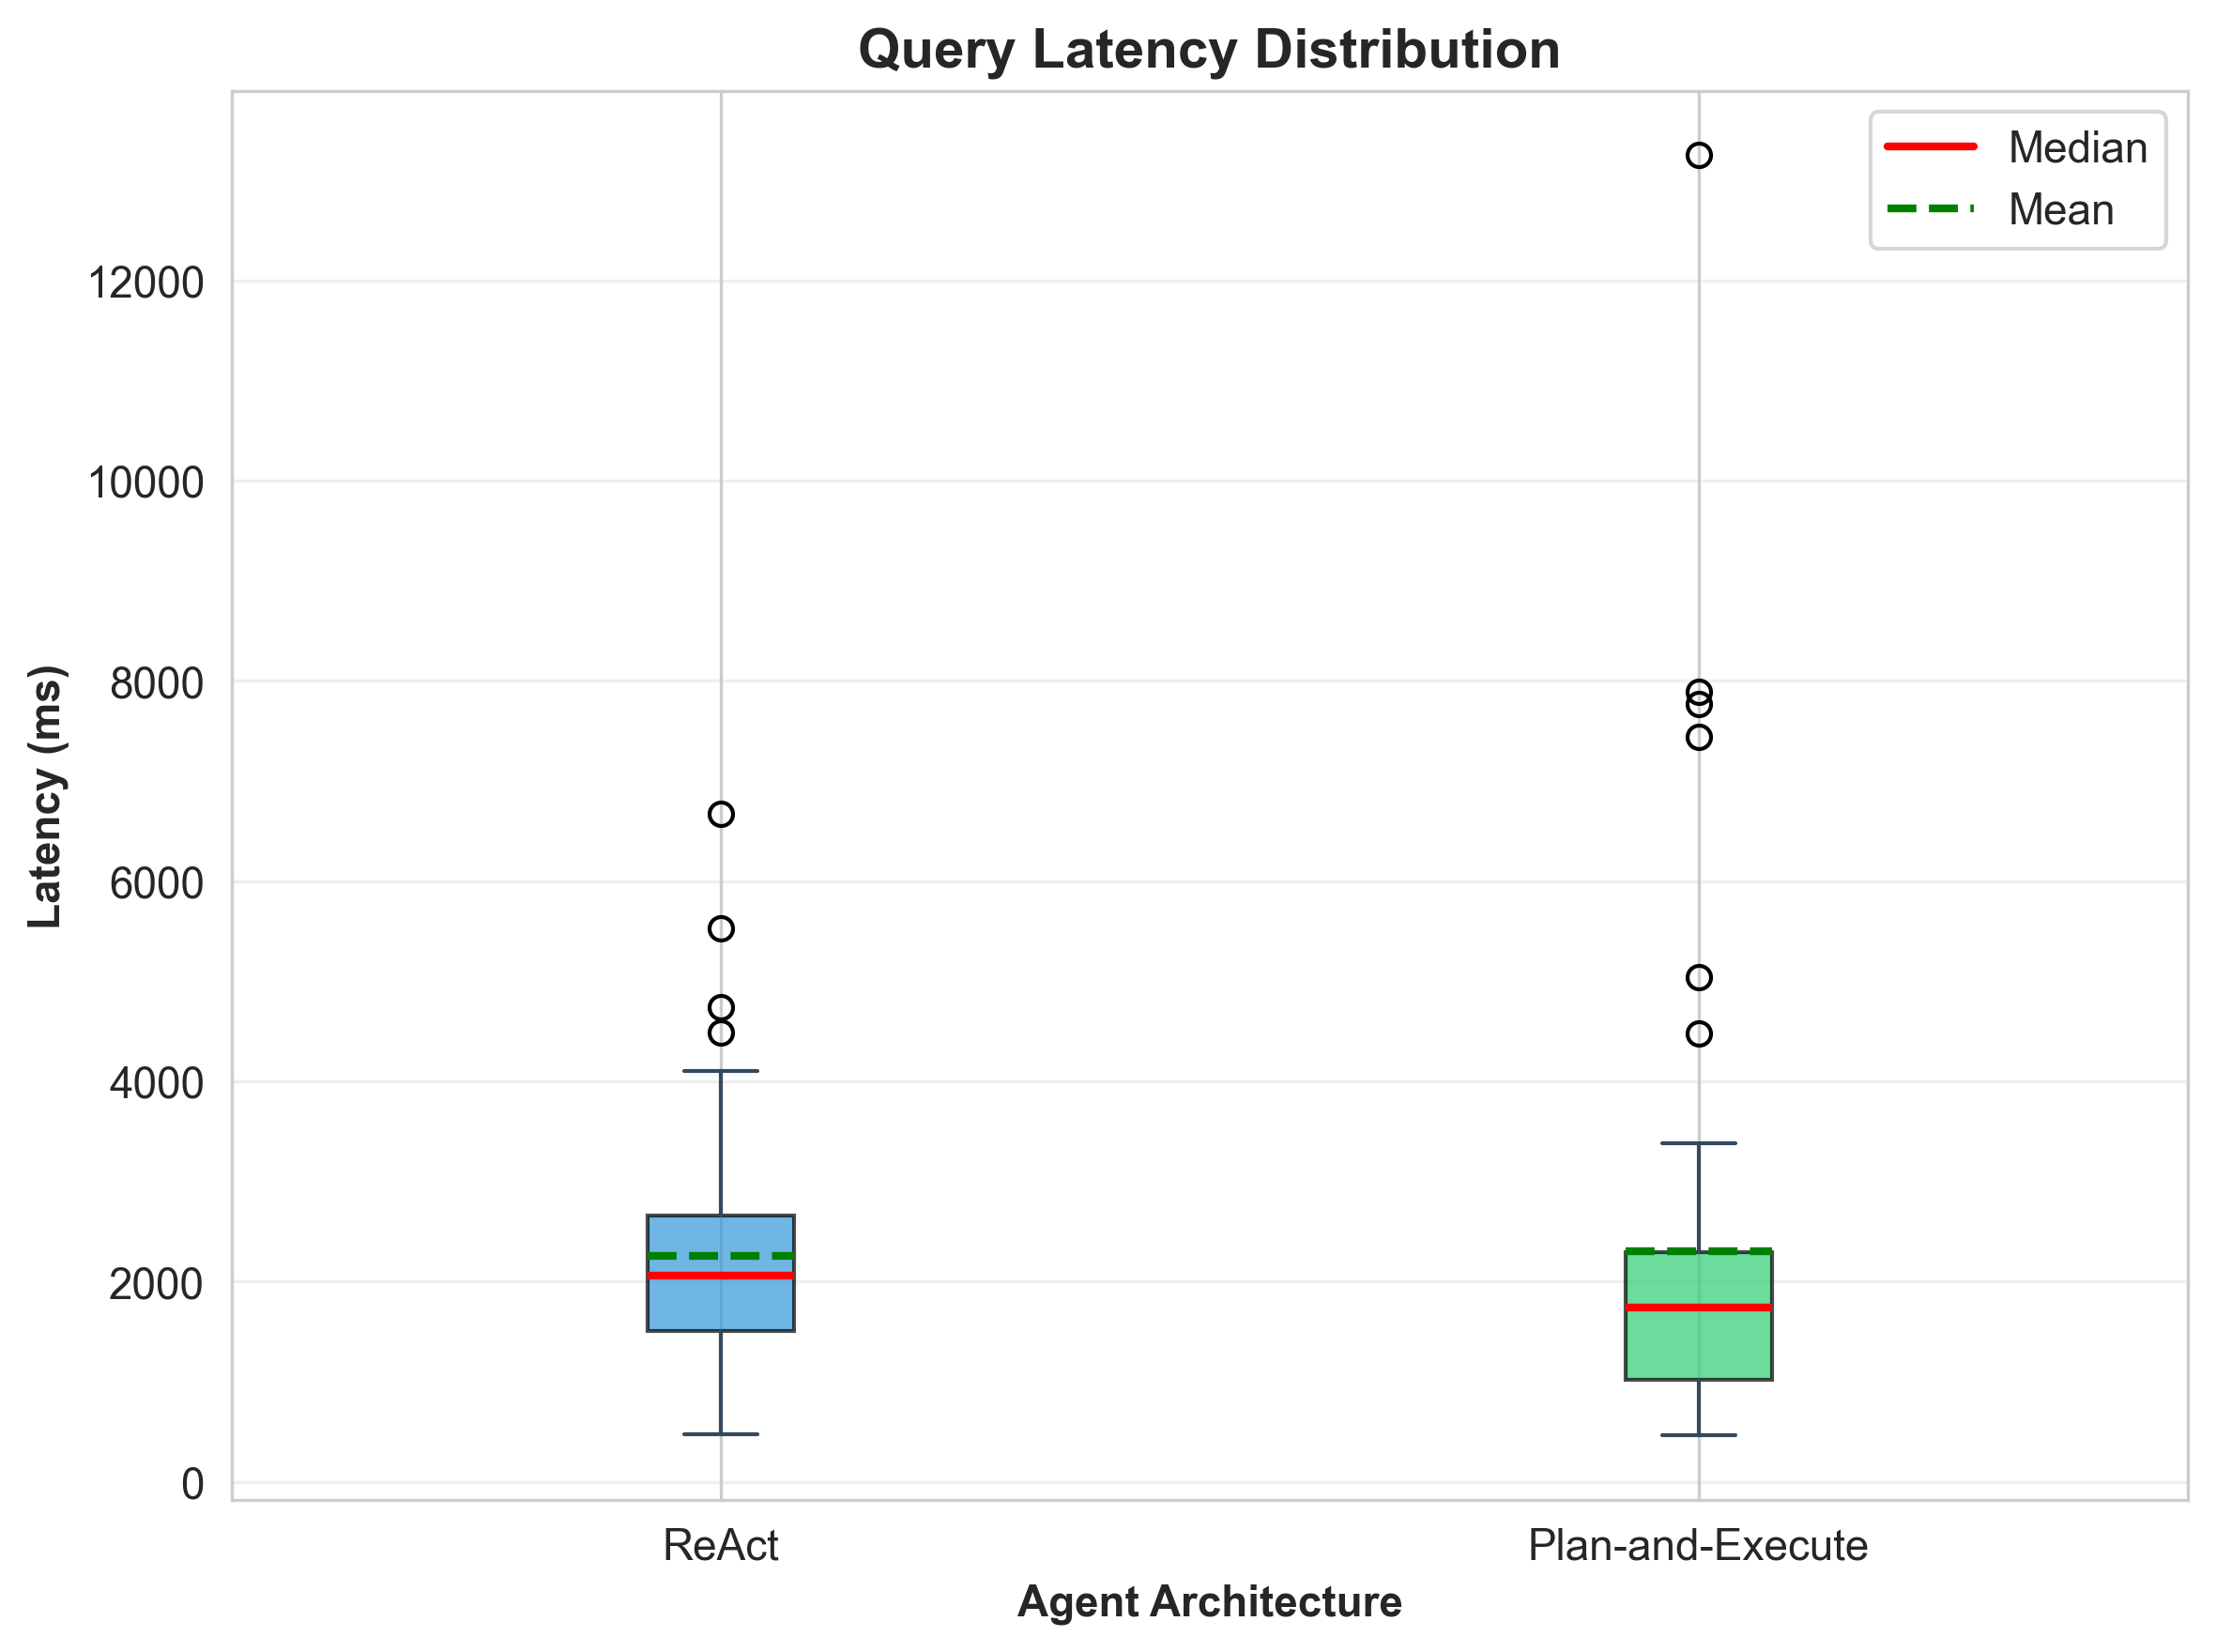

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

# Extract latency data from detailed results
react_latencies = [r["latency_ms"] for r in react_results]
plan_latencies = [r["latency_ms"] for r in plan_results]

# Prepare data for box plot
latency_data = [react_latencies, plan_latencies]
agent_labels = ["ReAct", "Plan-and-Execute"]

# Create box plot
bp = ax.boxplot(latency_data, labels=agent_labels, patch_artist=True,
                showmeans=True, meanline=True,
                boxprops=dict(alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                meanprops=dict(color='green', linewidth=2, linestyle='--'),
                whiskerprops=dict(color='#34495e'),
                capprops=dict(color='#34495e'))

# Color the boxes
colors = ['#3498db', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Formatting
ax.set_xlabel('Agent Architecture', fontweight='bold')
ax.set_ylabel('Latency (ms)', fontweight='bold')
ax.set_title('Query Latency Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add legend for median and mean
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linewidth=2, label='Median'),
    Line2D([0], [0], color='green', linewidth=2, linestyle='--', label='Mean')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
output_file = CHARTS_DIR / "03_latency_distribution.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"Saved: {output_file}")
plt.show()

## Chart 4: Iterations/Steps vs Latency

Scatter plot showing relationship between agent execution complexity (iterations for ReAct, steps for Plan-Execute) and latency.

Teaching note: Execution complexity
------------------------------------
This chart reveals:
- **Linear relationship**: More iterations/steps → higher latency (expected)
- **Outliers**: Queries with disproportionate latency (tool failures, LLM delays)
- **Efficiency**: Which agent completes queries with fewer LLM round-trips?

ReAct iterations vs Plan-Execute steps:
- ReAct: Each iteration = LLM call + optional tool call + observation
- Plan-Execute: Steps are pre-planned, executed sequentially

Saved: /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/charts/article_04/04_complexity_vs_latency.png


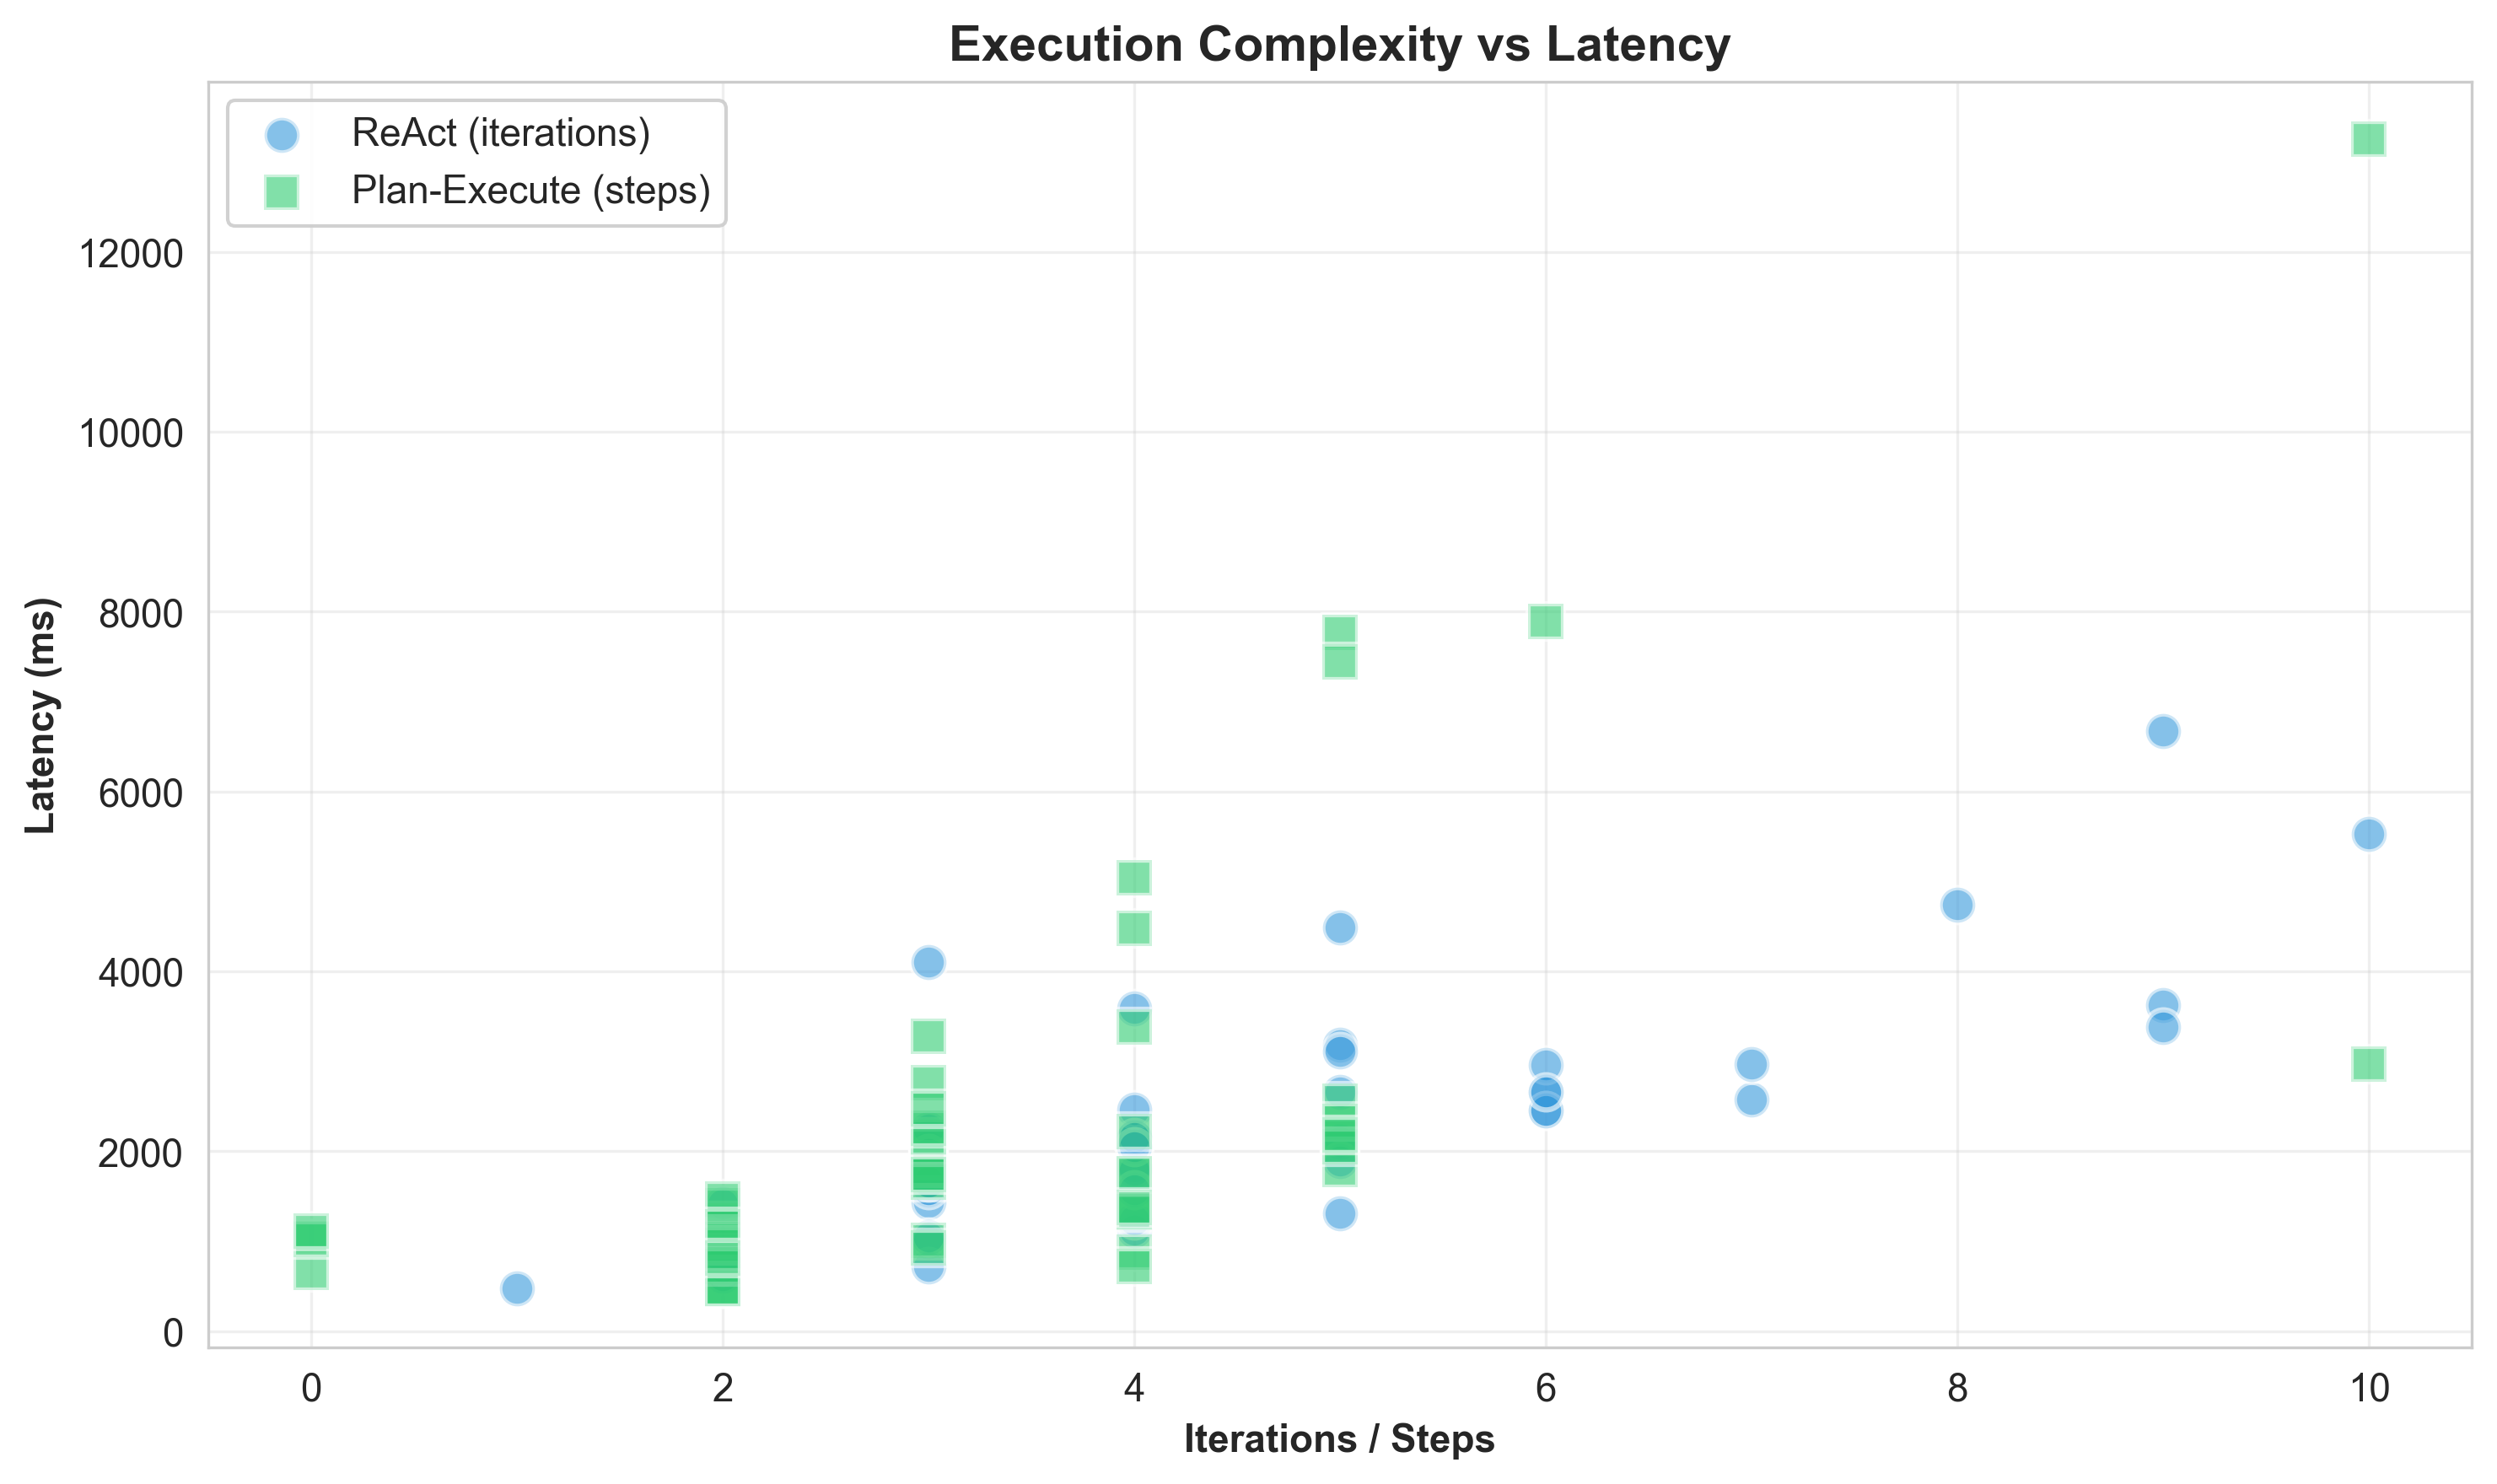

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Extract iterations and steps
react_iterations = [r.get("iterations", 0) for r in react_results]
react_latencies_for_scatter = [r["latency_ms"] for r in react_results]

plan_steps = [r.get("steps", 0) for r in plan_results]
plan_latencies_for_scatter = [r["latency_ms"] for r in plan_results]

# Plot ReAct
ax.scatter(react_iterations, react_latencies_for_scatter,
           s=100, alpha=0.6, color='#3498db', marker='o',
           label='ReAct (iterations)', edgecolors='white', linewidth=1.5)

# Plot Plan-Execute
ax.scatter(plan_steps, plan_latencies_for_scatter,
           s=100, alpha=0.6, color='#2ecc71', marker='s',
           label='Plan-Execute (steps)', edgecolors='white', linewidth=1.5)

# Formatting
ax.set_xlabel('Iterations / Steps', fontweight='bold')
ax.set_ylabel('Latency (ms)', fontweight='bold')
ax.set_title('Execution Complexity vs Latency', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
output_file = CHARTS_DIR / "04_complexity_vs_latency.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"Saved: {output_file}")
plt.show()

## Summary Statistics Table

Create a summary table comparing all key metrics.

In [8]:
summary_data = {
    "Agent": ["ReAct", "Plan-and-Execute"],
    "Trials": [
        str(len(react_results)),
        str(len(plan_results)),
    ],
    "Success Rate": [
        f"{react_summary['success_rate']:.1%}",
        f"{plan_summary['success_rate']:.1%}",
    ],
    "Avg Latency (ms)": [
        f"{react_summary['avg_latency_ms']:.0f}",
        f"{plan_summary['avg_latency_ms']:.0f}",
    ],
    "Median Latency (ms)": [
        f"{react_summary['median_latency_ms']:.0f}",
        f"{plan_summary['median_latency_ms']:.0f}",
    ],
    "Mean Trajectory Length": [
        f"{statistics.mean(react_iters):.2f} iters",
        f"{statistics.mean(plan_steps):.2f} steps",
    ],
    "Failures": [
        str(len(react_results) - sum(r['success'] for r in react_results)),
        str(len(plan_results) - sum(r['success'] for r in plan_results)),
    ],
}

summary_df = pd.DataFrame(summary_data)
print("\nSummary Statistics")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)



Summary Statistics
           Agent Trials Success Rate Avg Latency (ms) Median Latency (ms) Mean Trajectory Length Failures
           ReAct     51        94.1%             2259                2061             4.39 iters        3
Plan-and-Execute     51       100.0%             2299                1740             3.39 steps        0


## Results Interpretation

### What this run measures

3-category deterministic slice of the Article 4 query set: `rag_calculation`, `database_analysis`, `code_execution`. 17 unique queries x 3 runs = 51 trials per agent. The full 5-tool registry is loaded for both agents (`SearchTool`, `RAGTool`, `CalculatorTool`, `DatabaseLookupTool`, `CodeExecutionTool`). The two excluded categories (`multi_framework`, `failure_scenarios`) exist in the dataset but are intentionally omitted from headline numbers because their latency variance and rate-limit exposure would dominate aggregate comparisons.

### Headline finding

On this slice, Plan-and-Execute matched or beat ReAct on success-flag rate (51/51 vs 48/51), median latency (321 ms faster, ~14%), and trajectory length (3.4 plan steps vs 4.4 reasoning iterations). ReAct edged out P&E on mean latency by 40 ms - well inside the variance envelope, but worth naming honestly:

- **success-flag rate**: P&E 100% (51/51) vs ReAct 94.1% (48/51). The three ReAct failures returned `success=False` with iteration counts of 1, 3, and 3, well below the cap of 10. These are early-exit conditions in the reasoning loop, not timeouts.
- **Latency**: ReAct mean 2,259 ms vs P&E mean 2,299 ms (ReAct 40 ms faster, inside variance). ReAct median 2,061 ms vs P&E median 1,740 ms (P&E 321 ms faster, ~14%). The median delta is the meaningful signal; the mean delta is noise.
- **Trajectory length**: P&E mean 3.4 steps vs ReAct mean 4.4 iterations. Shorter trajectories on the same workload, with no convergence cost on the success flag.

The two architectures' "success rates" aren't strictly apples-to-apples: ReAct uses `next_action == "finish"` (`single_agent.py:760`) and P&E uses `final_answer is not None` (`single_agent.py:1256`). The 4 P&E zero-step "successes" exist precisely because P&E's bar is lower.

### Caveat on the P&E "100%" number

4/51 P&E trials had `steps=0` and finished in ~1 second, meaning the planner returned an empty plan and the synthesis node produced a final answer directly from LLM prior knowledge without executing any tools. They show up as `success=True` because the success flag in this runner is `final_answer is not None`, which only verifies the synthesis node populated the field - it does not verify the answer is correct, non-empty, or grounded in tool output. The remaining 47 P&E trials executed at least one plan step. The two trials at length 10 (the cap) executed the full plan and produced an answer, so they count as completion at the cap rather than truncation.

### Why the textbook framing inverts here

The textbook case for ReAct is adaptive recovery: when a tool output subverts the plan, ReAct rethinks and Plan-and-Execute commits to the original plan. That advantage shows up on workloads with genuinely novel branching. This 3-category slice is well-bounded (compute X from RAG, look up Y in the DB, execute Z code), so the planner's single shot is a feature, not a liability: fewer LLM calls, fewer chances to drift.

The comparison that would test the textbook case lives in the excluded categories. A follow-on run over `multi_framework` and `failure_scenarios` is the right way to measure that.

### Limitations of this run

- **Tool-call telemetry**: `tool_usage_histogram` is empty across the run because the runner reads `chat_history` looking for `role == "tool"`, but the agents emit `role == "assistant (action)"` (ReAct) or return `step_results` instead of `chat_history` (P&E). The agents demonstrably did execute tools - iterations and steps both exceed zero on most successful trials - but per-tool counts are not in the JSON.
- **Answer payload not persisted**: the runner captures the `answer` string into its in-memory dataclass but does not serialize it. The `success` flag is therefore the only outcome signal in the JSON, and it only checks whether `final_answer` was populated.
- **Statistical power**: 17 unique queries x 3 runs is enough to detect the 3/0 failure gap and the ~14% median latency difference, not enough for fine-grained per-tool or per-category claims.
- **Workload narrowness**: conclusions about Plan-and-Execute superiority apply to this slice only. The argument for ReAct is a workload that exercises adaptive recovery; this benchmark deliberately doesn't.


## Export Complete

Charts written to `results/charts/article_04/`:
- `01_success_rate.png`: success rate comparison
- `02_trajectory_length.png`: trajectory length histogram (iterations vs steps)
- `03_latency_distribution.png`: latency box plot
- `04_complexity_vs_latency.png`: trajectory length vs latency scatter
